In [24]:
# Cell 1: Install Required Libraries (run once)
# ============================================================

# Install medical imaging library
!pip install -q monai

# Install Grad-CAM for explainability
!pip install -q grad-cam

# Import basic libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import random

# Import torch (already on Kaggle)
import torch

# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
set_seed(42)

# Check if GPU is available
print("=" * 50)
print("✅ SETUP COMPLETE")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print("=" * 50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 26.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ SETUP COMPLETE
PyTorch version: 2.10.0+cu128
GPU Available: True
GPU Name: Tesla T4


In [25]:
# Cell 2: Load ISIC 2018 Dataset from Your Paths
# ============================================================

# Your base path
base_path = "/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation"

# Define all paths
train_img_path = os.path.join(base_path, "ISIC2018_Task1-2_Training_Input")
train_mask_path = os.path.join(base_path, "ISIC2018_Task1_Training_GroundTruth")
val_img_path = os.path.join(base_path, "ISIC2018_Task1-2_Validation_Input")
test_img_path = os.path.join(base_path, "ISIC2018_Task1-2_Test_Input")

# Helper function to get all image files from a folder
def get_image_files(folder_path):
    """Return list of all .jpg images in folder"""
    if not os.path.exists(folder_path):
        return []
    return sorted([f for f in os.listdir(folder_path) if f.endswith('.jpg')])

# Load all file names
train_images = get_image_files(train_img_path)
val_images = get_image_files(val_img_path)
test_images = get_image_files(test_img_path)

# For masks, they might be .png or .jpg
def get_mask_files(folder_path):
    """Return list of mask files (png or jpg)"""
    if not os.path.exists(folder_path):
        return []
    masks = []
    for f in os.listdir(folder_path):
        if f.endswith('.png') or f.endswith('.jpg'):
            masks.append(f)
    return sorted(masks)

train_masks = get_mask_files(train_mask_path)

print("=" * 50)
print("📁 DATASET LOADED SUCCESSFULLY")
print("=" * 50)
print(f"Training images: {len(train_images)}")
print(f"Training masks: {len(train_masks)}")
print(f"Validation images: {len(val_images)}")
print(f"Test images: {len(test_images)}")
print("=" * 50)

# Check if numbers match
print(f"\n✅ Train images and masks match: {len(train_images) == len(train_masks)}")

# Create a simple dataframe for training data
train_data = []
for img_file in train_images:
    # Get base name (remove .jpg)
    base_name = img_file.replace('.jpg', '')
    
    # Find matching mask (mask might have same name but different extension)
    mask_file = None
    for m in train_masks:
        if base_name in m:
            mask_file = m
            break
    
    if mask_file:
        train_data.append({
            'image_id': base_name,
            'image_path': os.path.join(train_img_path, img_file),
            'mask_path': os.path.join(train_mask_path, mask_file)
        })

df_train = pd.DataFrame(train_data)
print(f"\n✅ Created dataframe with {len(df_train)} matched pairs")
print("\nFirst 5 rows:")
df_train.head()

📁 DATASET LOADED SUCCESSFULLY
Training images: 2594
Training masks: 2594
Validation images: 100
Test images: 1000

✅ Train images and masks match: True

✅ Created dataframe with 2594 matched pairs

First 5 rows:


,image_id,image_path,mask_path
0,ISIC_0000000,/kaggle/input/datasets/tschandl/isic2018-chall...,/kaggle/input/datasets/tschandl/isic2018-chall...
1,ISIC_0000001,/kaggle/input/datasets/tschandl/isic2018-chall...,/kaggle/input/datasets/tschandl/isic2018-chall...
2,ISIC_0000003,/kaggle/input/datasets/tschandl/isic2018-chall...,/kaggle/input/datasets/tschandl/isic2018-chall...
3,ISIC_0000004,/kaggle/input/datasets/tschandl/isic2018-chall...,/kaggle/input/datasets/tschandl/isic2018-chall...
4,ISIC_0000006,/kaggle/input/datasets/tschandl/isic2018-chall...,/kaggle/input/datasets/tschandl/isic2018-chall...


## Visualize Sample Images and Masks

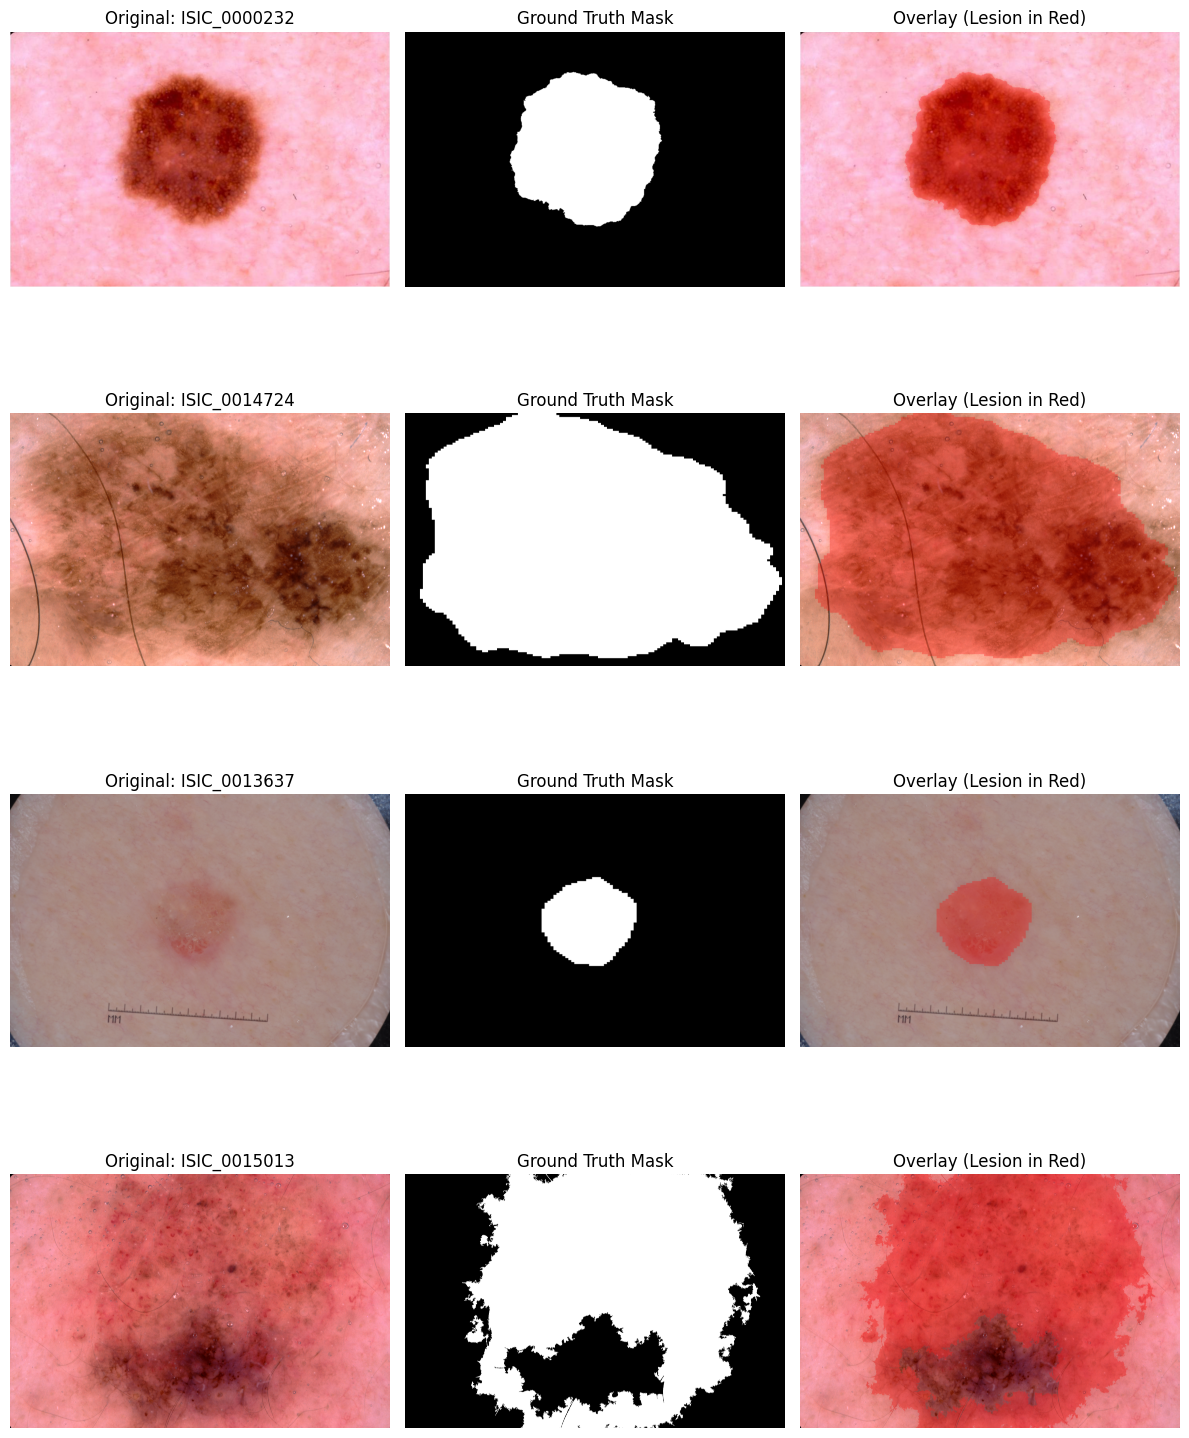

 DATASET INFORMATION
Image shape: (767, 1022, 3)
Mask shape: (767, 1022)
Mask unique values: [  0 255] (0=background, 1 or 255=lesion)


In [26]:
# Cell 3: Visualize Sample Images and Their Masks
# ============================================================

# Set number of samples to view
num_samples = 4

# Pick random samples from the dataframe
sample_rows = df_train.sample(n=num_samples, random_state=42)

# Create a figure with subplots
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

for idx, row in enumerate(sample_rows.iterrows()):
    row_data = row[1]
    
    # Load image
    img = cv2.imread(row_data['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    
    # Load mask (should be binary: 0=background, 1=lesion)
    mask = cv2.imread(row_data['mask_path'], cv2.IMREAD_GRAYSCALE)
    
    # Overlay mask on image (make mask semi-transparent red)
    overlay = img.copy()
    overlay[mask > 0] = [255, 0, 0]  # Red color for lesion
    
    # Blend original and overlay
    blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)
    
    # Plot original image
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f"Original: {row_data['image_id']}")
    axes[idx, 0].axis('off')
    
    # Plot mask
    axes[idx, 1].imshow(mask, cmap='gray')
    axes[idx, 1].set_title(f"Ground Truth Mask")
    axes[idx, 1].axis('off')
    
    # Plot overlay
    axes[idx, 2].imshow(blended)
    axes[idx, 2].set_title(f"Overlay (Lesion in Red)")
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

print(" DATASET INFORMATION")

sample_img = cv2.imread(df_train.iloc[0]['image_path'])
sample_mask = cv2.imread(df_train.iloc[0]['mask_path'], cv2.IMREAD_GRAYSCALE)
print(f"Image shape: {sample_img.shape}")
print(f"Mask shape: {sample_mask.shape}")
print(f"Mask unique values: {np.unique(sample_mask)} (0=background, 1 or 255=lesion)")
print("=" * 50)

## Generate Bounding Boxes from Masks

Generating bounding boxes...
Processing 0/2594...
Processing 500/2594...
Processing 1000/2594...
Processing 1500/2594...
Processing 2000/2594...
Processing 2500/2594...

📦 BOUNDING BOXES GENERATED
Total images: 2594
Failed (empty masks): 0

First 5 bounding boxes:


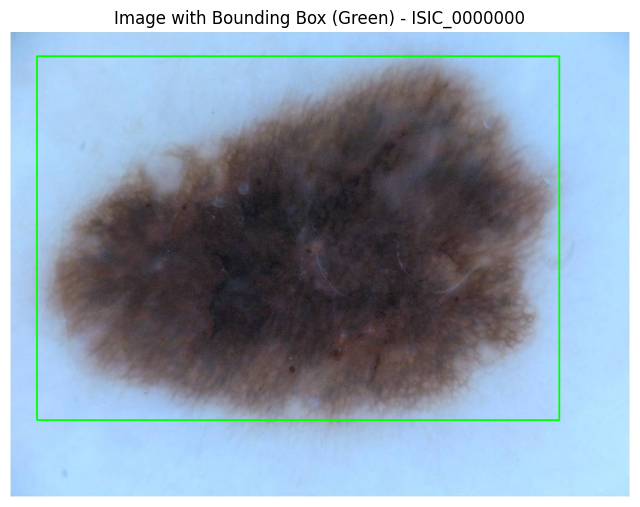

In [27]:
# Cell 4: Generate Bounding Boxes from Masks (for MedSAM prompts)
# ============================================================

def get_bounding_box_from_mask(mask_path):
    """
    Get bounding box coordinates from a segmentation mask.
    Returns: [x_min, y_min, x_max, y_max]
    """
    # Load mask
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # Convert to binary (0 or 255 -> 0 or 1)
    mask_binary = (mask > 0).astype(np.uint8)
    
    # Find coordinates where mask is 1
    y_coords, x_coords = np.where(mask_binary == 1)
    
    if len(x_coords) == 0 or len(y_coords) == 0:
        # If mask is empty, return None
        return None
    
    # Get min and max coordinates
    x_min = int(np.min(x_coords))
    x_max = int(np.max(x_coords))
    y_min = int(np.min(y_coords))
    y_max = int(np.max(y_coords))
    
    # Add small padding (5 pixels) to make box slightly larger
    padding = 5
    h, w = mask.shape
    x_min = max(0, x_min - padding)
    y_min = max(0, y_min - padding)
    x_max = min(w, x_max + padding)
    y_max = min(h, y_max + padding)
    
    return [x_min, y_min, x_max, y_max]

# Generate bounding boxes for all training images
print("Generating bounding boxes...")
bboxes = []
failed_images = []

for idx, row in df_train.iterrows():
    if idx % 500 == 0:
        print(f"Processing {idx}/{len(df_train)}...")
    
    bbox = get_bounding_box_from_mask(row['mask_path'])
    
    if bbox is None:
        failed_images.append(row['image_id'])
        bbox = [0, 0, 0, 0]  # Placeholder for empty mask
    
    bboxes.append({
        'image_id': row['image_id'],
        'x_min': bbox[0],
        'y_min': bbox[1],
        'x_max': bbox[2],
        'y_max': bbox[3]
    })

# Create dataframe for bounding boxes
df_bboxes = pd.DataFrame(bboxes)

print("\n" + "=" * 50)
print("📦 BOUNDING BOXES GENERATED")
print("=" * 50)
print(f"Total images: {len(df_bboxes)}")
print(f"Failed (empty masks): {len(failed_images)}")
print(f"\nFirst 5 bounding boxes:")
df_bboxes.head()

# Visualize a sample with bounding box
sample_idx = 0
sample_row = df_train.iloc[sample_idx]
sample_bbox = df_bboxes.iloc[sample_idx]

img = cv2.imread(sample_row['image_path'])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Draw bounding box
x_min, y_min, x_max, y_max = sample_bbox[['x_min', 'y_min', 'x_max', 'y_max']]
cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f"Image with Bounding Box (Green) - {sample_row['image_id']}")
plt.axis('off')
plt.show()

In [29]:
figures_dir = "/kaggle/working/pure_project_figures"
os.makedirs(figures_dir, exist_ok=True)

# FIGURE 1: One sample image with mask overlay (shows what the data looks like)
sample_row = df_train.iloc[0]
img = cv2.imread(sample_row['image_path'])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mask = cv2.imread(sample_row['mask_path'], cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

overlay = img.copy()
overlay[mask > 0] = [255, 0, 0]
blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)
axes[2].imshow(blended)
axes[2].set_title('Overlay (Lesion in Red)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "figure1_sample_data.png"), dpi=150, bbox_inches='tight')
plt.close()

# FIGURE 2: One sample bounding box (for MedSAM)
sample_bbox_row = df_bboxes.iloc[0]
sample_img_row = df_train.iloc[0]

img_bbox = cv2.imread(sample_img_row['image_path'])
img_bbox = cv2.cvtColor(img_bbox, cv2.COLOR_BGR2RGB)
x_min, y_min, x_max, y_max = sample_bbox_row[['x_min', 'y_min', 'x_max', 'y_max']]
cv2.rectangle(img_bbox, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(img_bbox)
plt.title('Bounding Box for MedSAM Prompt')
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "figure2_bounding_box.png"), dpi=150, bbox_inches='tight')
plt.close()

print(f"Location: {figures_dir}")
print("\nSaved figures:")


Location: /kaggle/working/pure_project_figures

Saved figures:


## Split Data into Train and Validation Sets

In [28]:
# Cell 5: Split Data into Train and Validation Sets
# ============================================================

from sklearn.model_selection import train_test_split

# Use 80% for training, 20% for validation
train_ratio = 0.8
val_ratio = 0.2

# Split the data
train_indices, val_indices = train_test_split(
    range(len(df_train)),
    test_size=val_ratio,
    random_state=42,
    shuffle=True
)

# Create train and validation dataframes
df_train_final = df_train.iloc[train_indices].reset_index(drop=True)
df_val = df_train.iloc[val_indices].reset_index(drop=True)

# Also split bounding boxes accordingly
df_bboxes_train = df_bboxes.iloc[train_indices].reset_index(drop=True)
df_bboxes_val = df_bboxes.iloc[val_indices].reset_index(drop=True)

print("=" * 50)
print("📊 DATA SPLIT COMPLETE")
print("=" * 50)
print(f"Total images: {len(df_train)}")
print(f"Training set: {len(df_train_final)} images ({train_ratio*100:.0f}%)")
print(f"Validation set: {len(df_val)} images ({val_ratio*100:.0f}%)")
print("=" * 50)

# Display distribution
print("\nTraining set sample:")
df_train_final.head(3)

print("\nValidation set sample:")
df_val.head(3)

📊 DATA SPLIT COMPLETE
Total images: 2594
Training set: 2075 images (80%)
Validation set: 519 images (20%)

Training set sample:

Validation set sample:


,image_id,image_path,mask_path
0,ISIC_0000232,/kaggle/input/datasets/tschandl/isic2018-chall...,/kaggle/input/datasets/tschandl/isic2018-chall...
1,ISIC_0014724,/kaggle/input/datasets/tschandl/isic2018-chall...,/kaggle/input/datasets/tschandl/isic2018-chall...
2,ISIC_0013637,/kaggle/input/datasets/tschandl/isic2018-chall...,/kaggle/input/datasets/tschandl/isic2018-chall...


## Saving Prepared Data to CSV Files

In [30]:
output_dir = "/kaggle/working/pure_project_data"
os.makedirs(output_dir, exist_ok=True)

# Save all dataframes
df_train_final.to_csv(os.path.join(output_dir, "train_data.csv"), index=False)
df_val.to_csv(os.path.join(output_dir, "val_data.csv"), index=False)
df_bboxes_train.to_csv(os.path.join(output_dir, "train_bboxes.csv"), index=False)
df_bboxes_val.to_csv(os.path.join(output_dir, "val_bboxes.csv"), index=False)

# Also save test image paths (no masks available for test)
test_image_list = []
for img_file in test_images:
    test_image_list.append({
        'image_id': img_file.replace('.jpg', ''),
        'image_path': os.path.join(test_img_path, img_file)
    })
df_test = pd.DataFrame(test_image_list)
df_test.to_csv(os.path.join(output_dir, "test_data.csv"), index=False)


print("DATA SAVED SUCCESSFULLY")

print(f"Saved to: {output_dir}")
print("\nFiles created:")
print(f"  - train_data.csv ({len(df_train_final)} rows)")
print(f"  - val_data.csv ({len(df_val)} rows)")
print(f"  - train_bboxes.csv ({len(df_bboxes_train)} rows)")
print(f"  - val_bboxes.csv ({len(df_bboxes_val)} rows)")
print(f"  - test_data.csv ({len(df_test)} rows)")
print("=" * 50)

# Verify files can be read back
print("\n Verification - Loading a file:")
test_load = pd.read_csv(os.path.join(output_dir, "train_data.csv"))
print(f"Successfully loaded: {test_load.shape[0]} rows")

# Show what's in each file
print("\ntrain_data.csv columns:")
print(df_train_final.columns.tolist())

print("\ntrain_bboxes.csv columns:")
print(df_bboxes_train.columns.tolist())

# Create a simple info file for reference
info_text = f"""

Data Split:
- Training: {len(df_train_final)} images
- Validation: {len(df_val)} images  
- Test: {len(df_test)} images (no masks available)

Files in this directory:
- train_data.csv: Image paths and mask paths for training
- val_data.csv: Image paths and mask paths for validation
- train_bboxes.csv: Bounding boxes for training images
- val_bboxes.csv: Bounding boxes for validation images
- test_data.csv: Test image paths (no masks)

Next Steps:
1. Notebook 2: Train U-Net + Generate Grad-CAM
2. Notebook 3: Run MedSAM + Compare Results
"""

with open(os.path.join(output_dir, "README.txt"), "w") as f:
    f.write(info_text)

print("\nCreated README.txt with dataset information")

DATA SAVED SUCCESSFULLY
Saved to: /kaggle/working/pure_project_data

Files created:
  - train_data.csv (2075 rows)
  - val_data.csv (519 rows)
  - train_bboxes.csv (2075 rows)
  - val_bboxes.csv (519 rows)
  - test_data.csv (1000 rows)

 Verification - Loading a file:
Successfully loaded: 2075 rows

train_data.csv columns:
['image_id', 'image_path', 'mask_path']

train_bboxes.csv columns:
['image_id', 'x_min', 'y_min', 'x_max', 'y_max']

Created README.txt with dataset information
